## Environment setup

This notebook needs `torch`, `torchvision`, `numpy`, `matplotlib`, `jupyter`, and a local install of the `spikingjelly` package (a vendored SpikingJelly fork in this repo).

If your environment does not already have these, create it from the repo's `environment.yml`:

```bash
conda env create -f environment.yml
conda activate cs6886_a3
```

Then select the `cs6886_a3` kernel for this notebook.

If you already have a working environment with the packages above installed (including `spikingjelly` built from `./spikingjelly/setup.py`), you can skip this step.


In [1]:
import torch
import torchvision
import torch.nn as nn
import spikingjelly
from spikingjelly.activation_based import ann2snn
from tqdm import tqdm
from spikingjelly.activation_based.ann2snn.examples import cnn_mnist as snn
from spikingjelly.activation_based.ann2snn.sample_models import mnist_cnn
import numpy as np
import matplotlib.pyplot as plt

/home/da24s023/.conda/envs/cs6886_a3/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


### **Task 1** is installing all prerequisites correctly so that the following imports run smoothly. (10 marks)

Install the correct version of torch if you wish to use CUDA.

Install the spikingjelly using the setup.py file only and not with pip using the command 'python setup.py install'.

In [2]:
# set Hyperparameters
snn.hyperparameters.T = 20
snn.hyperparameters.batch_size = 100

device = "cuda"  # use 'cpu' if CUDA not available
download_dataset = True  # downloads MNIST
dataset_dir = "./spikingjelly/datasets/mnist"
download_model = True  # downloads a 3 layer CNN classifier

if download_model:
    print("Downloading SJ-mnist-cnn_model-sample.pth...")
    ann2snn.download_url(
        "https://ndownloader.figshare.com/files/34960191",
        "./spikingjelly/SJ-mnist-cnn_model-sample.pth",
    )


model = mnist_cnn.CNN().to(device)
model.load_state_dict(torch.load("./spikingjelly/SJ-mnist-cnn_model-sample.pth"))
print(model)

CNN(
  (network): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (8): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Linear(in_features=32, out_features=10, bias=True)
  )
)


We see the specification of our CNN, having three Conv blocks with [Conv, BatchNorm2d, ReLU, AvgPool2d] modules.

### **Task 2** is calculating the number of MAC operations in each Conv layer. (10 Marks)


Below we take the first two Conv blocks (first 8 modules) as a backbone and the rest of the model as the head.

We freeze the backbone, convert the head to an SNN and evaluate using snn.main.

In [3]:
conv_macs = snn.compute_conv_macs(model.network, device=device)

for name, macs in conv_macs.items():
    print(f"{name}: {macs:,} MACs")
print(f"Total: {sum(conv_macs.values()):,} MACs")

conv1 (layer 0): 194,688 MACs
conv2 (layer 4): 1,115,136 MACs
conv3 (layer 8): 82,944 MACs
Total: 1,392,768 MACs


In [4]:
split_index = 8
backbone = model.network[:split_index]
head = model.network[split_index:]
snn_head, vals = snn.main(
    eval_fn=snn.val,
    backbone=backbone,
    head=head,
    conversion=snn.conversion_job,
    download_dataset=download_dataset,
    device="cuda",
    dataset_dir=dataset_dir,
)
print(vals)

---------------------------------------------
Converting using preset='1/4 max' (mode=0.25)


100%|██████████| 600/600 [00:06<00:00, 89.32it/s]


Simulating...


Counting spikes (train set): 100%|██████████| 600/600 [00:07<00:00, 76.17it/s]

[0.9799 0.9841 0.9838 0.9841 0.9834 0.9846 0.9845 0.984  0.9844 0.9836
 0.9841 0.9844 0.9843 0.9841 0.9841 0.9844 0.984  0.9842 0.984  0.984 ]


main() has returned the converted model head and also its accuracy for number of timesteps from 1 to T.


We provided a conversion algorithm to snn.main. Go to the file spikingjelly\activation_based\ann2snn\examples\cnn_mnist.py to see how this is defined in snn.conversion_job().

You should see some commented out code snippets for other possible conversion jobs. 

You can make your own conversion job using any one of those and pass it into snn.main()


### **Task 3** is plotting accuracy vs time steps for all the mentioned conversion jobs in one plot. (10 Marks)

Pick the conversion job that gives best results for you. Stick to this algorithm for all further tasks.

In [5]:
sweep_results = {}
for preset in snn.conversion_config.presets:
    snn.conversion_config.preset = preset
    _, vals = snn.main(
        eval_fn=snn.val,
        backbone=backbone,
        head=head,
        conversion=snn.conversion_job,
        download_dataset=download_dataset,
        device=device,
        dataset_dir=dataset_dir,
    )
    sweep_results[preset] = vals

---------------------------------------------
Converting using preset='max' (mode='max')


100%|██████████| 600/600 [00:06<00:00, 87.26it/s]


Simulating...


Counting spikes (train set): 100%|██████████| 600/600 [00:07<00:00, 75.13it/s]


---------------------------------------------
Converting using preset='99.9%' (mode='99.9%')


...

Counting spikes (train set): 100%|██████████| 600/600 [00:07<00:00, 75.21it/s]


---------------------------------------------
Converting using preset='1/4 max' (mode=0.25)


100%|██████████| 600/600 [00:06<00:00, 85.84it/s]


Simulating...


Counting spikes (train set): 100%|██████████| 600/600 [00:08<00:00, 74.92it/s]


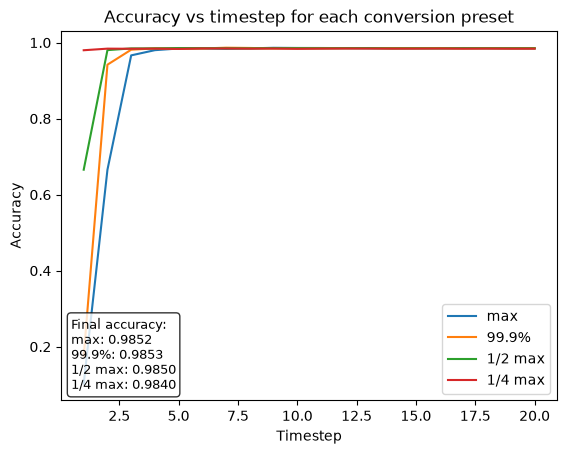

Selected conversion preset: 1/4 max


In [6]:
plt.figure()
for name, vals in sweep_results.items():
    plt.plot(range(1, len(vals) + 1), vals, label=name)
plt.xlabel("Timestep")
plt.ylabel("Accuracy")
plt.title("Accuracy vs timestep for each conversion preset")
plt.legend()

summary = "Final accuracy:\n" + "\n".join(
    f"{name}: {vals[-1]:.4f}" for name, vals in sweep_results.items()
)
plt.gca().text(
    0.02,
    0.02,
    summary,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment="bottom",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)
plt.show()

# We aim to choose the preset that reaches within TOLERANCE of its own peak accuracy in the fewest timesteps.
# Fewer timesteps means fewer spikes per inference, i.e. lower energy cost
# This approach rewards fast convergence instead of just picking whichever preset has the single highest number at the final timestep (T)
TOLERANCE = 0.005


def timesteps_to_converge(vals):
    peak = vals.max()
    return next(t for t, v in enumerate(vals, start=1) if v >= peak - TOLERANCE)


snn.conversion_config.preset = min(
    sweep_results,
    key=lambda name: (
        timesteps_to_converge(sweep_results[name]),
        -sweep_results[name][-1],
    ),
)
print("Selected conversion preset:", snn.conversion_config.preset)

### **Task 4** is plotting accuracy vs time steps for the original CNN, 1 conv block converted, 2 blocks converted, 3 blocks in one plot. (10 Marks)

In [7]:
split_configs = {
    "1 block converted": 4,
    "2 blocks converted": 8,
    "3 blocks converted": None,  # None -> backbone=None, head=full network (fully converted)
}

task4_results = {}
for name, split_index in split_configs.items():
    backbone_i = model.network[:split_index] if split_index is not None else None
    head_i = model.network[split_index:] if split_index is not None else model.network
    _, vals = snn.main(
        eval_fn=snn.val,
        backbone=backbone_i,
        head=head_i,
        conversion=snn.conversion_job,
        download_dataset=download_dataset,
        device=device,
        dataset_dir=dataset_dir,
    )
    task4_results[name] = vals

---------------------------------------------
Converting using preset='1/4 max' (mode=0.25)


  9%|▉         | 55/600 [00:00<00:04, 136.16it/s]

100%|██████████| 600/600 [00:04<00:00, 140.33it/s]


Simulating...


Counting spikes (train set): 100%|██████████| 600/600 [00:06<00:00, 98.08it/s]


...

Counting spikes (train set): 100%|██████████| 600/600 [00:07<00:00, 75.58it/s]


---------------------------------------------
Converting using preset='1/4 max' (mode=0.25)


100%|██████████| 600/600 [00:01<00:00, 592.93it/s]


Simulating...


Counting spikes (train set): 100%|██████████| 600/600 [00:04<00:00, 147.38it/s]


In [8]:
# Original (unconverted) CNN accuracy
test_dataset = torchvision.datasets.MNIST(
    root=dataset_dir,
    train=False,
    transform=torchvision.transforms.ToTensor(),
    download=download_dataset,
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=snn.hyperparameters.batch_size,
    shuffle=True,
    drop_last=False,
)
model.eval()
correct = 0.0
total = 0.0
with torch.no_grad():
    for img, label in test_loader:
        img, label = img.to(device), label.to(device)
        out = model(img)
        correct += (out.argmax(dim=1) == label).float().sum().item()
        total += img.shape[0]
ann_accuracy = correct / total

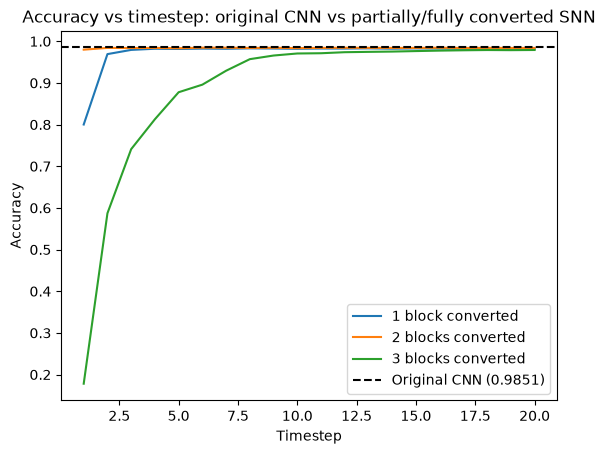

In [9]:
plt.figure()
for name, vals in task4_results.items():
    plt.plot(range(1, len(vals) + 1), vals, label=name)
plt.axhline(
    ann_accuracy,
    color="black",
    linestyle="--",
    label=f"Original CNN ({ann_accuracy:.4f})",
)
plt.xlabel("Timestep")
plt.ylabel("Accuracy")
plt.title("Accuracy vs timestep: original CNN vs partially/fully converted SNN")
plt.legend()
plt.show()

## Now let us look at the converted model.

In [10]:
print(snn_head)

Sequential(
  (8): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (11): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (12): Flatten(start_dim=1, end_dim=-1)
  (13): Linear(in_features=32, out_features=10, bias=True)
  (): Module(
    (voltage_hook_0): VoltageHook()
    (spiking0): Module(
      (scaler0): VoltageScaler(0.437881)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
        (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
      )
      (scaler1): VoltageScaler(2.283727)
    )
  )
)



def forward(self, input):
    input_1 = input
    _8 = getattr(self, "8")(input_1);  input_1 = None
    _spiking0_scaler0 = getattr(self, "").spiking0.scaler0(_8);  _8 = None
    _spiking0_if_node = getattr(self, "").spiking0.if_node(_spiking0_scaler0);  _spiking0_scaler0 = None
    _spiking0_scaler1 = getattr(self, "").spiking0.scaler1(_spiking0_if_node);  _spiking0_if_node = None
    _11 = getattr(self, "11")(_spiking0

SpikingJelly has changed the forward pass of the model significantly. 

In the framework the original Conv2d layer is used but only to simulate the scaling for the inputs to the IF neurons striped across time.
Hence we can use the number of spikes generated multiplied by the fan-out of the layer to estimate the number of accumulate operations (refer https://doi.org/10.3389/fnins.2017.00682)

We use val() in main() after conversion is complete. It evaluates the model on the train dataset and also registers a hook that stores spike counts of a IFNode layer in the model into snn.spike_counts. Dividing this by the size of the dataset provides an average for spike count per layer in a forward pass.

In [11]:
print(snn.spike_counts)

{'spiking0.if_node': 2051795580.0, 'spiking1.if_node': 648855242.0, 'spiking2.if_node': 91735430.0}


Go to the file spikingjelly\activation_based\ann2snn\examples\cnn_mnist.py to see how snn.val() is defined

We use val() in main() after conversion is complete. It evaluates the model on the train dataset and also registers a hook that stores spike counts of a IFNode layer in the model into snn.spike_counts.

Write your own custom_val() functions so that you can register hooks to the IFNode() modules for storing spike counts into a dictionary/list for different converted models. (You should need to make minimal changes to val(). Printing a model out might help you figure out how to assign the right hooks.)

### Task 5 is getting average spike count in all layers for a forward pass of a fully converted SNN. (10 Marks)

For a fully converted SNN, use snn.main(custom_val, backbone = None, head = model.network).

**Assume that energy cost of a MAC is 4.6nJ and cost of an accumulate op is 0.6nJ.** Using these values you can estimate the energy savings in converting a layer.

In [12]:
fully_converted_snn, vals = snn.main(
    eval_fn=snn.val,  # I've edited the original val() to generically work with any SNN. ALso fixed it to compute spike counts on train as instructed in the comments. Previously, it was computing spike counts on the test set.
    backbone=None,
    head=model.network,
    conversion=snn.conversion_job,
    download_dataset=download_dataset,
    device=device,
    dataset_dir=dataset_dir,
)

---------------------------------------------
Converting using preset='1/4 max' (mode=0.25)


 20%|█▉        | 119/600 [00:00<00:00, 588.46it/s]

100%|██████████| 600/600 [00:01<00:00, 592.11it/s]


Simulating...


Counting spikes (train set): 100%|██████████| 600/600 [00:04<00:00, 147.77it/s]


In [13]:
print(fully_converted_snn)

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (8): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (11): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (12): Flatten(start_dim=1, end_dim=-1)
  (13): Linear(in_features=32, out_features=10, bias=True)
  (): Module(
    (voltage_hook_0): VoltageHook()
    (voltage_hook_1): VoltageHook()
    (voltage_hook_2): VoltageHook()
    (spiking0): Module(
      (scaler0): VoltageScaler(0.701674)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
        (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
      )
      (scaler1): VoltageScaler(1.425162)
    )
    (spiking1): Module(
      (scaler0): VoltageScaler(1.166900)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=

In [14]:
train_dataset = torchvision.datasets.MNIST(
    root=dataset_dir,
    train=True,
    transform=torchvision.transforms.ToTensor(),
    download=download_dataset,
)
num_images = len(train_dataset)
avg_spikes = {name: total / num_images for name, total in snn.spike_counts.items()}
avg_spikes

{'spiking0.if_node': 34196.593,
 'spiking1.if_node': 10814.254033333333,
 'spiking2.if_node': 1528.9238333333333}

### Task 6 is reporting the best accuracy for an energy savings of 90% or higher. (15 Marks)

**Search strategy:** rather than pick a conversion split/timestep/preset by hand, we search the space of `(blocks_converted, T, preset)` combinations in parallel and pick the best result under the 90% energy-savings constraint.

We started broad (96 configs: all 3 splits × 8 timesteps × 4 presets) to see where the qualifying region was, then narrowed twice:
- Every config that reached ≥90% savings used `blocks_converted=3` (fully converted) — partial conversions leave too many MAC-cost layers running as ANN to hit 90% savings, so `block_options` is now fixed at `(3,)`.
- Accuracy peaked around `T=5`, so `T_options` is narrowed to the band `(4, 5, 6, 7, 8)` around it.
- The `"1/4 max"` preset saturates within a single timestep at a low accuracy ceiling and never appeared near the top of the ranking, so it's dropped from the final search.

The search evaluates multiple configurations evaluate in parallel.

In [15]:
conv_macs = snn.compute_conv_macs(model.network, device=device)
fan_out = snn.compute_fan_out(model.network)
ann_energy = sum(conv_macs.values()) * 4.6

results_task6 = snn.search_conversion_configs(
    "./spikingjelly/SJ-mnist-cnn_model-sample.pth",
    conv_macs,
    fan_out,
    ann_energy,
    block_options=(3,),  # every config that reached >=90% savings in earlier searches used blocks_converted=3 (fully converted); 1/2-block conversions never qualified
    T_options=(4, 5, 6, 7, 8),  # narrowed to the band around the empirical peak (T=5) found by two earlier, wider sweeps (56 and 96 configs)
    presets=("max", "99.9%", "1/2 max"),  # dropped "1/4 max": it saturates within 1 timestep at a low accuracy ceiling and never appeared near the top in earlier sweeps
    device=device,
    dataset_dir=dataset_dir,
    download_dataset=download_dataset,
    max_workers=32,
)

qualifying_task6 = [r for r in results_task6 if r["energy_savings"] >= 0.90]
best_task6 = max(qualifying_task6, key=lambda r: r["accuracy"]) if qualifying_task6 else None

print(f"{len(qualifying_task6)} / {len(results_task6)} configs reach >=90% energy savings")
if best_task6 is not None:
    print(
        f"Best accuracy at >=90% energy savings: {best_task6['accuracy']:.4f} "
        f"(blocks_converted={best_task6['blocks_converted']}, T={best_task6['T']}, "
        f"preset={best_task6['preset']!r}, energy_savings={best_task6['energy_savings']:.4f})"
    )
else:
    print("No configuration reached 90% energy savings.")

9 / 15 configs reach >=90% energy savings
Best accuracy at >=90% energy savings: 0.7552 (blocks_converted=3, T=5, preset='99.9%', energy_savings=0.9238)


### Task 7 is reporting the best energy savings you could achieve from ANN conversion for a loss in accuracy less than 5% from the original CNN. (15 Marks)

Remember, you can scale number of time steps (snn.hyperparameters.T) to scale both computation and accuracy.

In [16]:
results_task7 = snn.search_conversion_configs(
    "./spikingjelly/SJ-mnist-cnn_model-sample.pth",
    conv_macs,
    fan_out,
    ann_energy,
    block_options=(2,),  # every one of the top energy-savings configs across two earlier, wider sweeps (96 and 56 configs) used blocks_converted=2; 3-block (fully converted) configs that beat their savings all failed the <5% accuracy-loss constraint
    T_options=(1, 2, 3, 4, 5),  # energy savings falls monotonically as T rises while accuracy only rises, so the optimum is always the smallest T that still qualifies; nothing above T=5 can beat what's already been found at T=3
    presets=None,  # search every preset
    device=device,
    dataset_dir=dataset_dir,
    download_dataset=download_dataset,
    max_workers=32,
)

qualifying_task7 = [r for r in results_task7 if ann_accuracy - r["accuracy"] < 0.05]
best_task7 = max(qualifying_task7, key=lambda r: r["energy_savings"]) if qualifying_task7 else None

print(f"{len(qualifying_task7)} / {len(results_task7)} configs have accuracy loss < 5% from the original CNN ({ann_accuracy:.4f})")
if best_task7 is not None:
    print(
        f"Best energy savings with <5% accuracy loss: {best_task7['energy_savings']:.4f} "
        f"(blocks_converted={best_task7['blocks_converted']}, T={best_task7['T']}, "
        f"preset={best_task7['preset']!r}, accuracy={best_task7['accuracy']:.4f})"
    )
else:
    print("No configuration kept accuracy loss under 5%.")

9 / 20 configs have accuracy loss < 5% from the original CNN (0.9851)
Best energy savings with <5% accuracy loss: 0.8456 (blocks_converted=2, T=3, preset='1/2 max', accuracy=0.9590)




So far we have used a really optimistic cost model which only considers energy required for compute operations; we have ignored the costs of writing our compute results to memory.
In reality activation maps are typically too large to fit entirely in CPU cache, especially in vision models. DRAM writes of a 64 byte vector are ~10-50nj and could easily be upwards of 100nj when activating different DRAM rows.

Efficient vision model pipelines try to take maximum advantage of tiling and operator fusion so that computation is focused on smaller regions of the activation map which can fit into cache memory. SRAM writes average around ~1-3nj per vector write across different levels, but this approach introduces a tradeoff between memory traffic and recomputation.

Assume you have a compute pipeline for vision models with high bandwidth memory where performing writes costs 25nj per 64 bytes on average across the available memory hierarchy. Ignore the costs of loading weights, hence only your activation maps contribute to memory-related energy costs. Treat the Conv2d, BatchNorm, ReLU and AvgPool operations within a block as fused for the purpose of memory accounting.

### Task 8 is calculating the memory-related energy costs of each layer in one forward pass of the CNN model. (5 Marks)

Assume these are also the memory-related energy cost of one timestep of running a converted SNN layer. Running the model for multiple time steps incurs this cost at each timestep.

### Task 9 is to report the best energy savings you could achieve from ANN conversion for a loss in accuracy less than 5% with the memory-aware cost model. (15 Marks)

This should highlight the importance of neuromorphic memory innovations like in-memory compute and asynchronous core design.
